In [1]:
# Exercise 2: Analyzing network properties

In [2]:
#install.packages("poweRlaw")

In [3]:
# Load relevant libraries
# Extensive documentation for iGraph here: http://igraph.org/r/doc/
suppressMessages(library(igraph))

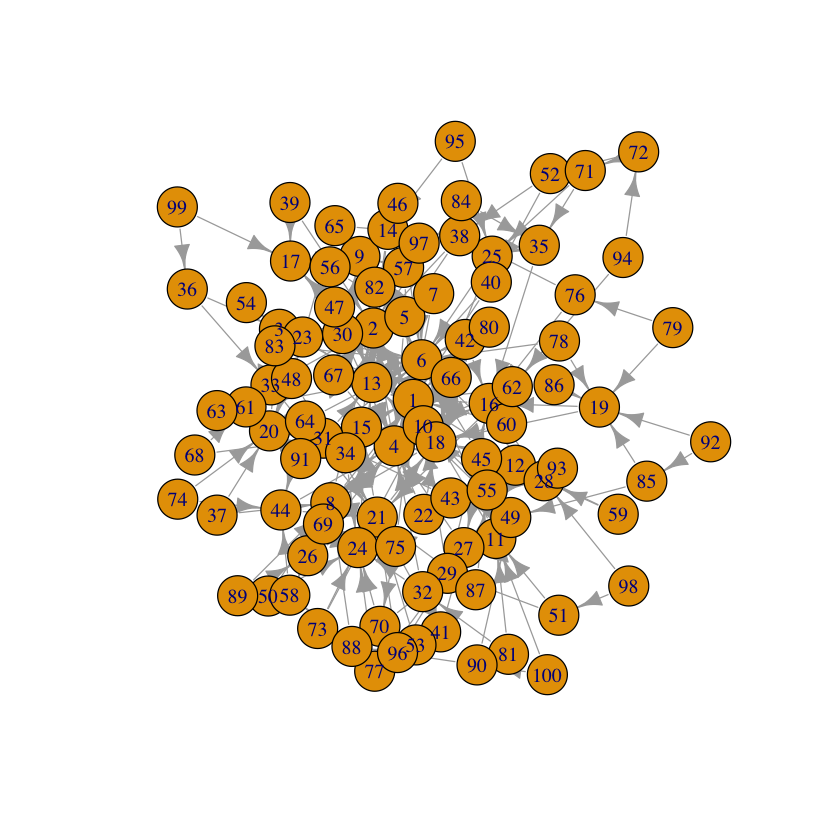

In [4]:
# Create a network to analyze
# We will discuss the sample_pa() command in more detail later
test.graph <-sample_pa(100,power=0.5,m=2)
plot.igraph(test.graph)

In [5]:
#?sample_pa

sample_pa {igraph},R Documentation
n,Number of vertices.
power,"The power of the preferential attachment, the default is one, i.e. linear preferential attachment."
m,"Numeric constant, the number of edges to add in each time step This argument is only used if both out.dist and out.seq are omitted or NULL."
out.dist,"Numeric vector, the distribution of the number of edges to add in each time step. This argument is only used if the out.seq argument is omitted or NULL."
out.seq,Numeric vector giving the number of edges to add in each time step. Its first element is ignored as no edges are added in the first time step.
out.pref,"Logical, if true the total degree is used for calculating the citation probability, otherwise the in-degree is used."
zero.appeal,The ‘attractiveness’ of the vertices with no adjacent edges. See details below.
directed,Whether to create a directed graph.
algorithm,"The algorithm to use for the graph generation. psumtree uses a partial prefix-sum tree to generate the graph, this algorithm can handle any power and zero.appeal values and never generates multiple edges. psumtree-multiple also uses a partial prefix-sum tree, but the generation of multiple edges is allowed. Before the 0.6 version igraph used this algorithm if power was not one, or zero.appeal was not one. bag is the algorithm that was previously (before version 0.6) used if power was one and zero.appeal was one as well. It works by putting the ids of the vertices into a bag (multiset, really), exactly as many times as their (in-)degree, plus once more. Then the required number of cited vertices are drawn from the bag, with replacement. This method might generate multiple edges. It only works if power and zero.appeal are equal one."
start.graph,"NULL or an igraph graph. If a graph, then the supplied graph is used as a starting graph for the preferential attachment algorithm. The graph should have at least one vertex. If a graph is supplied here and the out.seq argument is not NULL, then it should contain the out degrees of the new vertices only, not the ones in the start.graph."


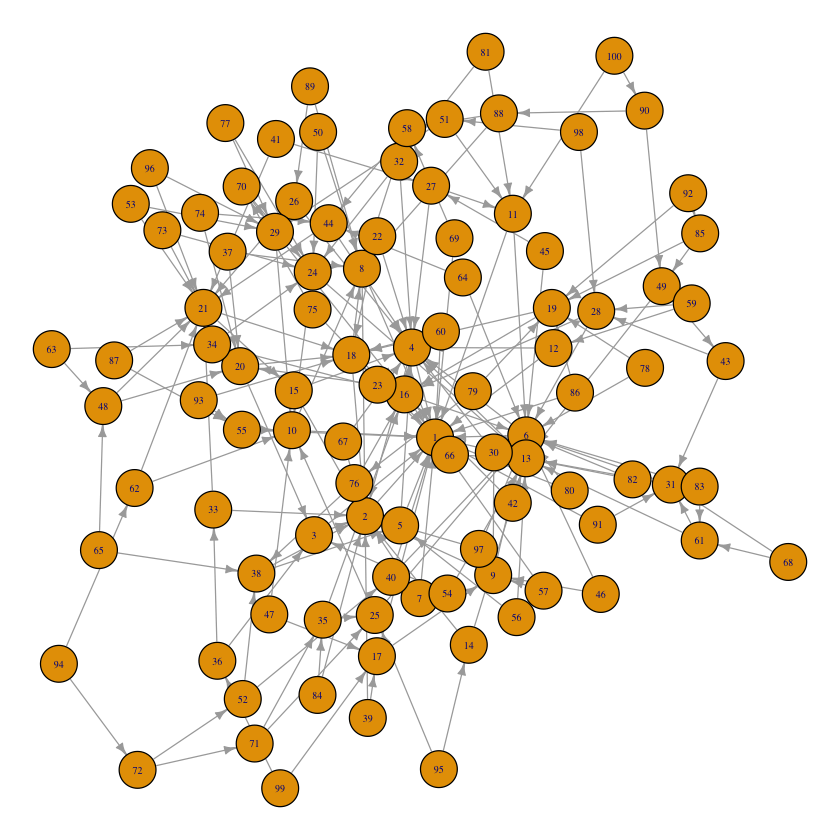

In [6]:
# Plot using a layout algorithm and setting parameters to make the 
# network easier to look at
par(mar=c(.1,.1,.1,.1)) # Reduce margins around plot
plot.igraph(test.graph, layout=layout.fruchterman.reingold,
vertex.size=10,         # sets size of the vertex, default is 15
vertex.label.cex=.5,    # size of the vertex label
edge.arrow.size=.5        # sets size of the arrow at the end of the edge
)

In [7]:
# Overview of the graph
# How large is the network? (This was set when we made the network, but what if it hadn't been?)
 
test.graph      # Returns that it is an IGRAPH object with 100 nodes and 197 links,
                # made with the Barabasi algorithm with parameter settings
                # as well as the edge list up to a certain count
V(test.graph)   # gives the vertex sequence|
E(test.graph)   # gives the edge sequence (edge list)

# To retrieve the adjacency matrix
test.graph.adj<-as_adjacency_matrix(test.graph,sparse=F)
# Note: if you don't specify sparse=F you get a matrix of 1s and .s
#test.graph.adj

IGRAPH e816948 D--- 100 197 -- Barabasi graph
+ attr: name (g/c), power (g/n), m (g/n), zero.appeal (g/n), algorithm
| (g/c)
+ edges from e816948:
 [1]  2-> 1  3-> 1  3-> 2  4-> 1  4-> 2  5-> 1  5-> 4  6-> 1  6-> 4  7-> 2
[11]  7-> 1  8-> 1  8-> 2  9-> 2  9-> 6 10-> 1 10-> 8 11-> 6 11-> 1 12-> 1
[21] 12-> 4 13-> 1 13-> 4 14-> 2 14->13 15-> 4 15-> 2 16-> 4 16-> 1 17-> 9
[31] 17-> 1 18-> 2 18-> 8 19->18 19->16 20-> 3 20->18 21->15 21->18 22->18
[41] 22-> 4 23-> 6 23->20 24->13 24->10 25-> 6 25->10 26-> 4 26->21 27->11
[51] 27-> 4 28-> 6 28->16 29->10 29->16 30-> 9 30-> 4 31->13 31-> 6 32->24
[61] 32-> 4 33-> 2 33->21 34->16 34->24 35->16 35->25 36-> 3 36->33 37-> 8
+ ... omitted several edges

+ 100/100 vertices, from e816948:
  [1]   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
 [19]  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
 [37]  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
 [55]  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
 [73]  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
 [91]  91  92  93  94  95  96  97  98  99 100

+ 197/197 edges from e816948:
  [1]  2-> 1  3-> 1  3-> 2  4-> 1  4-> 2  5-> 1  5-> 4  6-> 1  6-> 4  7-> 2
 [11]  7-> 1  8-> 1  8-> 2  9-> 2  9-> 6 10-> 1 10-> 8 11-> 6 11-> 1 12-> 1
 [21] 12-> 4 13-> 1 13-> 4 14-> 2 14->13 15-> 4 15-> 2 16-> 4 16-> 1 17-> 9
 [31] 17-> 1 18-> 2 18-> 8 19->18 19->16 20-> 3 20->18 21->15 21->18 22->18
 [41] 22-> 4 23-> 6 23->20 24->13 24->10 25-> 6 25->10 26-> 4 26->21 27->11
 [51] 27-> 4 28-> 6 28->16 29->10 29->16 30-> 9 30-> 4 31->13 31-> 6 32->24
 [61] 32-> 4 33-> 2 33->21 34->16 34->24 35->16 35->25 36-> 3 36->33 37-> 8
 [71] 37->20 38-> 5 38-> 2 39->17 39-> 2 40-> 1 40-> 6 41->21 41->27 42->13
 [81] 42->16 43->28 43->31 44-> 4 44->21 45-> 6 45->27 46-> 9 46-> 6 47->17
 [91] 47->10 48->20 48->21 49->43 49->13 50-> 8 50->24 51->11 51->29 52->40
+ ... omitted several edges

In [8]:
# Graph properties

# Short function to return some standard graph properties
graph_properties <- function(g) {
  n <- vcount(g)
  m <- ecount(g)
  directed <- is_directed(g)

  list(
    N = n,                           # number of nodes
    Ltot = m,                        # number of edges
    LD = if (directed) m / n else 2 * m / n,
    C = edge_density(g, loops = FALSE),
    directed = directed
  )
}

test.graph.properties <- graph_properties(test.graph)

test.graph.properties$N #number of nodes
test.graph.properties$Ltot #number of links (i.e. edges)
test.graph.properties$LD #link density (average # of links per node, i.e. average node degree)
test.graph.properties$C #the edge density of the graph

# Edge density (called 'Connectance' in ecology) is a measure of completeness of a graph, comparing the
# number of observed edges to the number of possible edges
# It can be measured as L/(N*(N-1)) where L is links (edges), and N is nodes
# It can also be calculated as L/(N^2)

str(test.graph.properties)
names(test.graph.properties)


[1] 100

[1] 197

[1] 1.97

[1] 0.01989899

List of 5
 $ N       : num 100
 $ Ltot    : num 197
 $ LD      : num 1.97
 $ C       : num 0.0199
 $ directed: logi TRUE


[1] "N"        "Ltot"     "LD"       "C"        "directed"

[1] 22 15  5 15  4 17  2  9  6  8  6  3 12  3  3  9  5  9  7  6 12  2  2  8  5
 [26]  3  4  5  7  2  6  3  3  3  4  3  2  5  2  3  2  2  3  5  2  2  2  4  4  2
 [51]  3  3  2  2  4  2  2  4  2  2  4  3  2  2  2  2  2  2  2  3  3  3  2  2  2
 [76]  3  2  2  2  2  2  2  2  2  3  2  2  3  2  3  2  2  2  2  2  2  2  2  2  2

all.deg.testgraph
 2  3  4  5  6  7  8  9 12 15 17 22 
49 20  8  6  4  2  2  3  2  2  1  1 

[1] 49

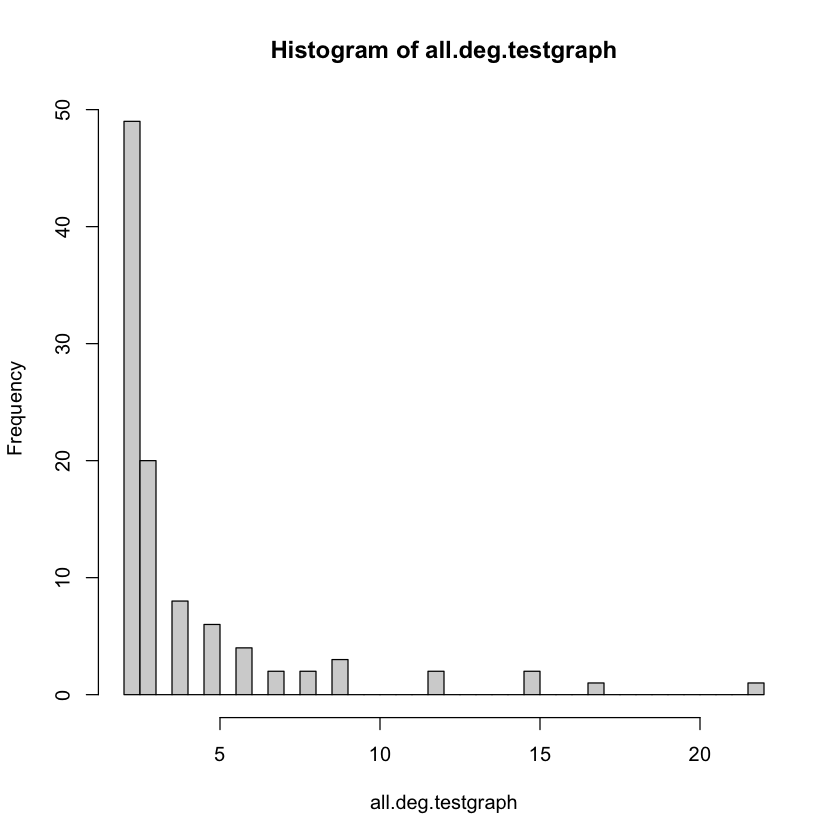

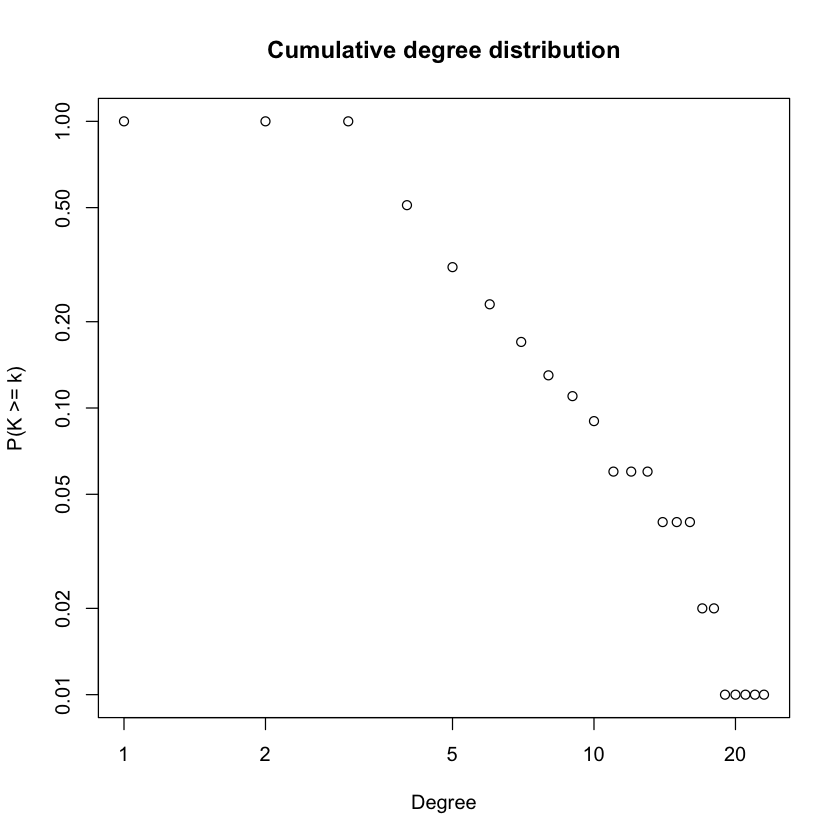

In [9]:
# Node degree distributions

# The degree of a node refers to the number of edges associated with a node.
# Degree can be measured as the edges going in ("in degree"), out ("out degree"), or both.
# The degree() function takes a graph input and gives the degree of specified nodes.
# With the argument "v=V(graph)" you tell the function to give the degree of all nodes in the graph,
# while the "mode" argument specifies in, out, or both.
 
in.deg.testgraph<-degree(test.graph,v=V(test.graph),mode="in")
out.deg.testgraph<-degree(test.graph,v=V(test.graph),mode="out")
all.deg.testgraph<-degree(test.graph,v=V(test.graph),mode="all")

# Count & plot the number of times nodes with degree n appear in the graph
all.deg.testgraph
table(all.deg.testgraph)
deg.counts <- table(all.deg.testgraph)
max(deg.counts)
hist(all.deg.testgraph,breaks=50) #,prob=T)
#lines(density(deg.counts)) # Use with prob=T

# Degree distribution is the cumulative frequency of nodes with a given degree
# this, like degree() can be specified as "in", "out", or "all"
deg.distr<-degree_distribution(test.graph,cumulative=T,mode="all")
plot(deg.distr, log = "xy",
     xlab = "Degree",
     ylab = "P(K >= k)",
     main = "Cumulative degree distribution")

List of 5
 $ continuous: logi FALSE
 $ alpha     : num 2.47
 $ xmin      : num 2
 $ logLik    : num -180
 $ KS.stat   : num 0.0203


[1] "continuous" "alpha"      "xmin"       "logLik"     "KS.stat"

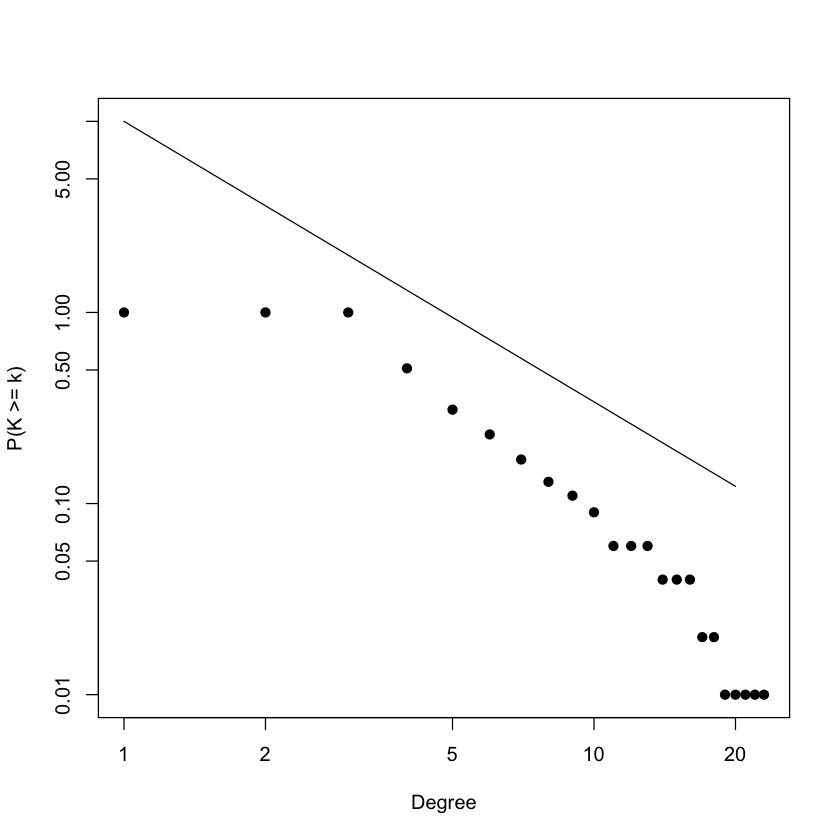

In [10]:
# Is the network scale-free?
# We can test this by comparing the node degree distribution to the 
# power-law distribution expected based on the graphs parameters

# Using the fit_power_law() function you can fit a power law to the degree distribution
power<-fit_power_law(all.deg.testgraph)
 
# The output of the fit_power_law() function gives the exponent of the power law ($alpha)
# and the log-likelihood of the parameters used to fit the power law distribution ($logLik)
# Also, it performs a Kolmogov-Smirnov test to determine whether the given degree distribution 
# could have been drawn from the fitted power law distribution.
# The function returns a test statistic ($KS.stat) and p-value ($KS.p) for that test

# Then we can plot the degree distribution
plot(deg.distr,log="xy",
ylim=c(.01,10),
bg="black",pch=21,
xlab="Degree",
ylab="P(K >= k)")
 
# And add a line corresponding to the expected power law distribution
lines(1:20,10*(1:20)^((-power$alpha)+1))
 
# Note: The KS test is used to determine if 2 distributions are 
# statistically different, thus the null hypothesis is that the 
# distributions are the same, and the p-value is used to reject
# the null hypothesis of same-ness
str(power)
names(power)

In [11]:
# To evaluate whether the degree distribution is power law distributed you need to run a montecarlo simulation
# This is because when we estimate the alpha parameter from the data, we violate an assumption of the KS test that
# we are comparing to a fully specified null distribution that is independent from our data
library(poweRlaw)
m <- displ$new(all.deg.testgraph)
est <- estimate_xmin(m)
m$setXmin(est)

bootstrap <- bootstrap_p(m, no_of_sims = 1000)

bootstrap$p
# This approach compares the observed deviation (KS test statistic) to a distribution of expected deviations 
# under a power law assumption
# p-value	        Interpretation
# p ≥ 0.1	        Data are consistent with a power law; cannot reject the hypothesis.
# 0.05 ≤ p < 0.1	Weak evidence against power law; ambiguous.
# p < 0.05	        Reject the power-law model; deviations are too large.

Expected total run time for 1000 sims, using 1 threads is 22.5 seconds.



[1] 0.959

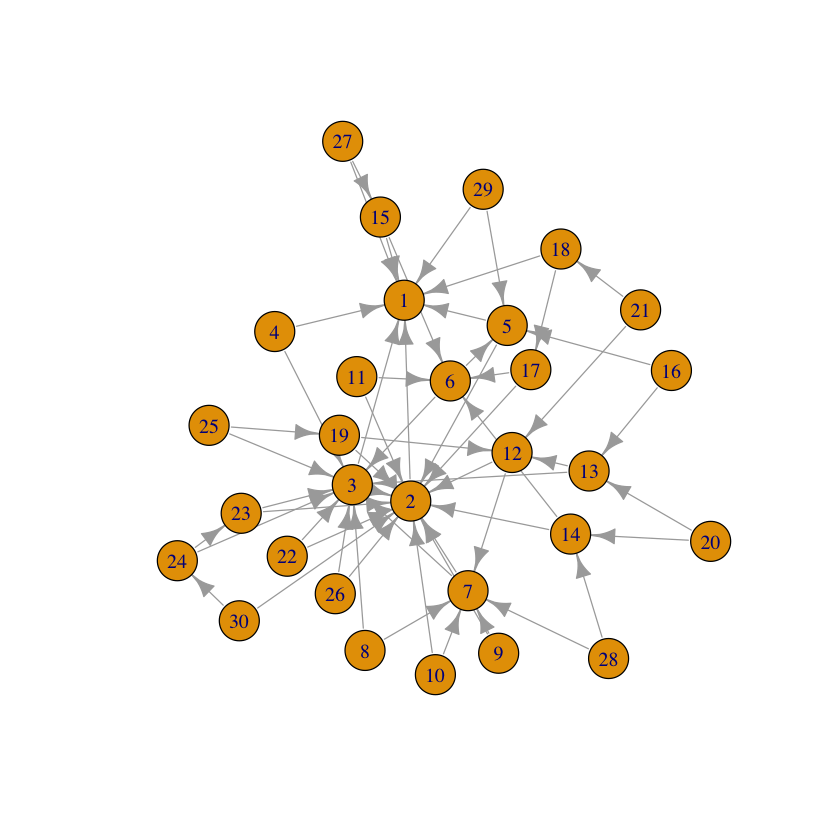

In [12]:
test.graph <-sample_pa(30,power=0.5,m=2)
plot.igraph(test.graph)

[1] 4

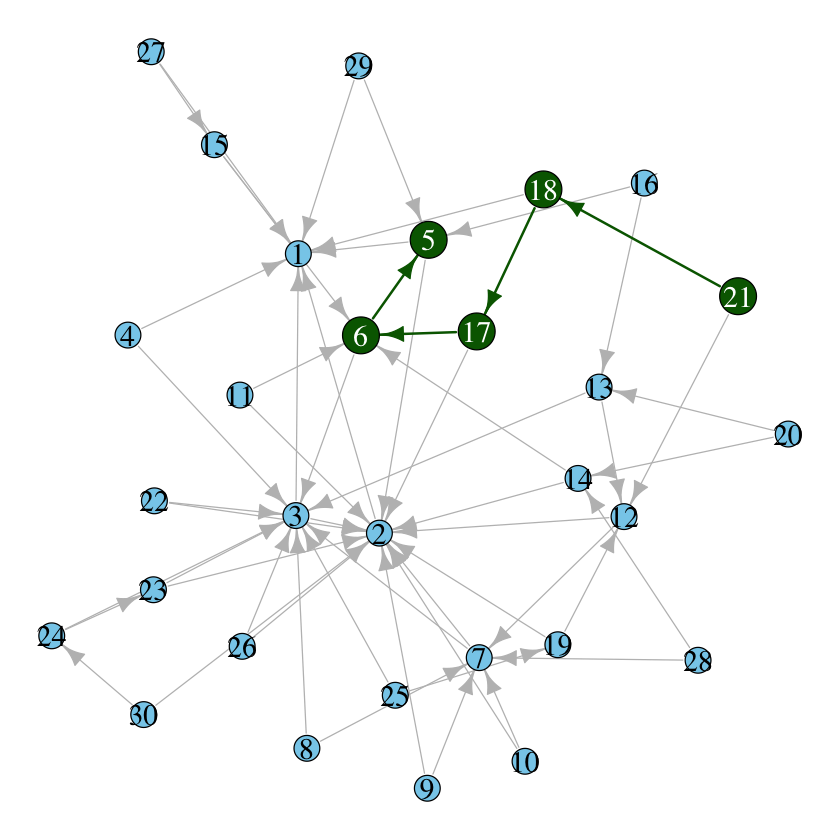

In [13]:
# Graph Diameter
# Diameter is the longest shortest path between two vertices
diameter(test.graph) # Gives the length of the diameter
nodes.diameter<-get_diameter(test.graph) # Gives the labels for each node that participate in the diameter
 
# To visualize the diameter
# First define the node and edge attributes
V(test.graph)$color<-"skyblue" # node default color
V(test.graph)$size<-7 # node default size
V(test.graph)[nodes.diameter]$color<-"darkgreen" # diameter node color
V(test.graph)[nodes.diameter]$size<-10 # diameter node size
V(test.graph)[nodes.diameter]$label.color<-"white" # diameter node label color

E(test.graph)$color<-"grey" # all non-diameter edges will be grey
E(test.graph,path=nodes.diameter)$color<-"darkgreen" # diameter edges will be dark green
E(test.graph)$width<-1
E(test.graph,path=nodes.diameter)$width<-2 # diameter edges will be wider
 
# If you do not set the attributes of all of the nodes and edges then it will
# default such that you only see what you have defined

#pdf(title = "test.pdf",width = 2, height = 2,pointsize=12)
par(mar=c(.1,.1,.1,.1))
plot.igraph(test.graph,
vertex.label.cex=1.5,
edge.arrow.size=1)
#dev.off()

In [14]:
# Properties informative about "small-worldness" of networks

# Clustering coefficient, betweenness, and closeness
# all describe the small world properties of the network.
# A network with small world properties is one in which
# it takes a relatively short path to get from one node to the next
# (e.g., six degrees of separation)

# Clustering coefficient is the proportion of
# a nodes neighbors that can be reached by other neighbors
# in igraph this property is apparently called "transitivity"
 
transitivity(test.graph)
# gives the clustering coefficient of the whole network
 
head(transitivity(test.graph,type="local"))
# gives the clustering coefficient of each node
 
# Betweenness is the number of shortest paths between two nodes that go through each node of interest
graph.betweenness<-betweenness(test.graph,v=V(test.graph))
head(graph.betweenness)

# The edge betweenness score of an edge measures the number of shortest paths through it
graph.edge.betweenness<-edge_betweenness(test.graph,e=E(test.graph))
head(graph.edge.betweenness)
 
# Closeness refers to how connected a node is to its neighbors
graph.closeness<-closeness(test.graph,vids=V(test.graph))
head(graph.closeness)



[1] 0.15

[1] 0.1785714 0.0952381 0.1212121 1.0000000 0.2000000 0.0000000

[1]  0.00000 11.16667 11.83333  0.00000  5.00000 17.00000

[1] 12.166667  8.333333  5.500000  2.000000  1.000000  4.500000

[1]       NaN 1.0000000 0.5000000 0.2500000 0.5000000 0.1666667

[1] 1 2 4 5 6 3

[1] 1 4 5 2 6 3

[1] 1 4 5 6 2 3

[1] 1 2 5 4 6 3

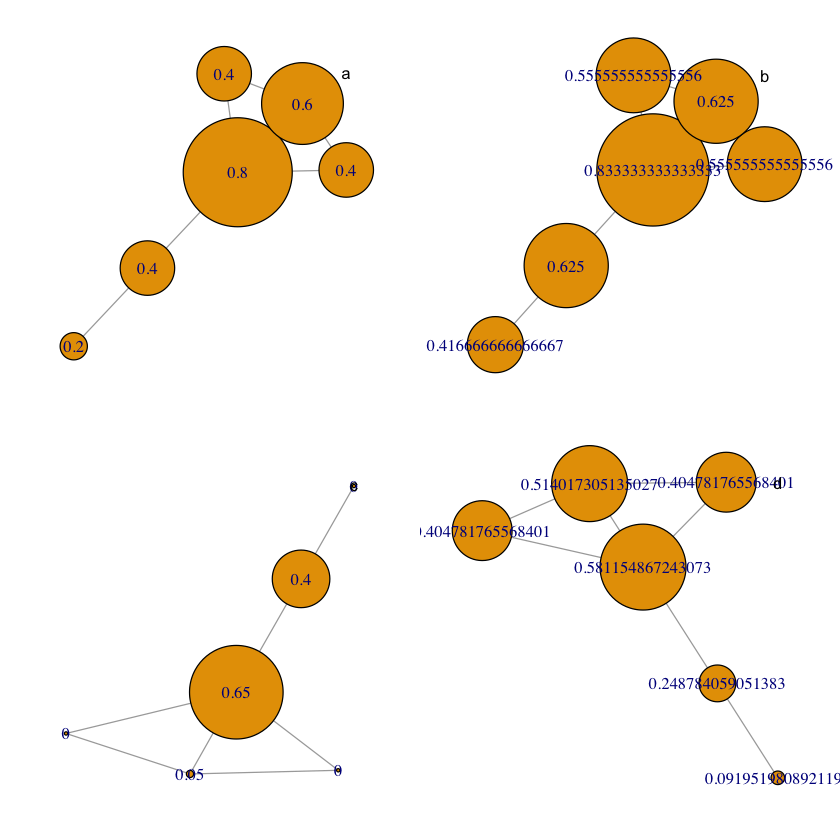

In [21]:
# Compare graph properties for similar graphs 
#g <- graph.formula(A-B,B-C,C-D,D-E)
#g <- graph.formula(A-B,A-C,A-D,A-E,A-F)
g <- graph.formula(A-B,B-C,C-D,C-E,C-F,D-F,E-F)

# Uncomment to get a simple list of values for each node
# Degree
#degree(g,normalized=T)
# Closeness (inverse of average dist)
#closeness(g,normalized=T)
# Betweenness
#betweenness(g,normalized=T)
# Local cluster coefficient - Doesn't make sense for very simple examples
#transitivity(g, type="local")
# Eigenvector centrality
#evcent(g,scale=F)$vector

# Now rank them
order(degree(g))
order(closeness(g))
#order(transitivity(g,type="local"))
order(betweenness(g))
order(eigen_centrality(g,scale=T)$vector)

txt<-c("a","b","c","d")    # vector for labeling the graphs
par(mfrow=c(2,2),mar=c(.2,.2,.2,.2))
plot.igraph(g,vertex.size=100*degree(g,normalized=T),vertex.label=degree(g,normalized=T),layout=layout.auto,frame=T)
text(1,1,txt[1]) 
plot.igraph(g,vertex.size=100*closeness(g,normalized=T),vertex.label=closeness(g,normalized=T),layout=layout.auto,frame=T)
text(1,1,txt[2]) 
plot.igraph(g,vertex.size=100*betweenness(g,normalized=T),vertex.label=betweenness(g,normalized=T),layout=layout.auto,frame=T)
text(1,1,txt[3]) 
plot.igraph(g,vertex.size=100*eigen_centrality(g,scale=F)$vector,vertex.label=evcent(g,scale=F)$vector,layout=layout.auto,frame=T)
text(1,1,txt[4]) 

In [22]:
#?eigen_centrality

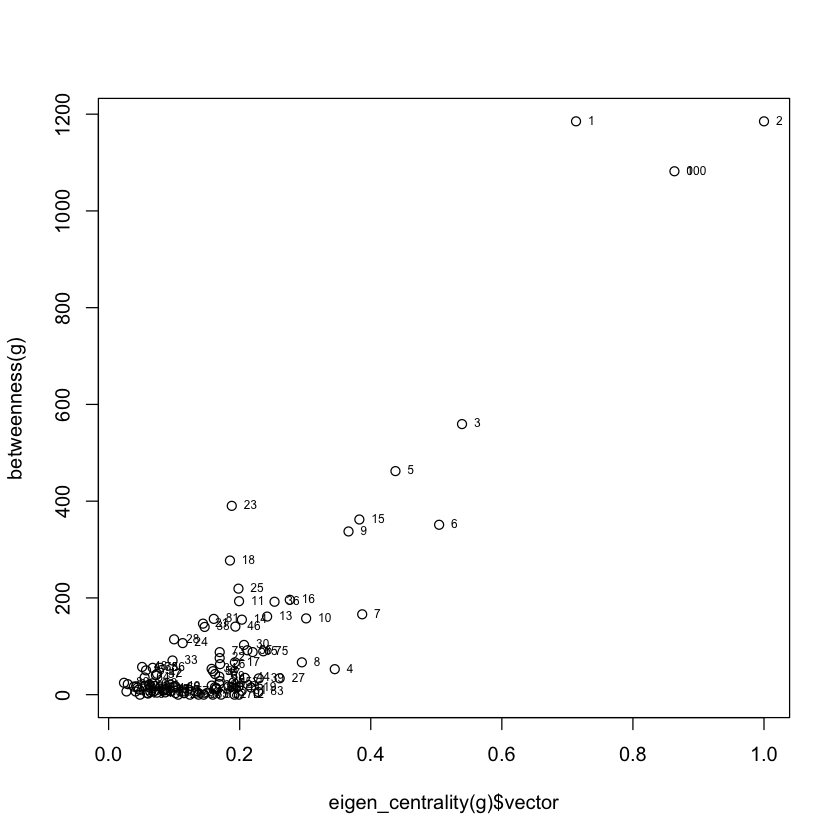

In [23]:
# Centrality measures applied:
# Nodes with different roles in regulating 'information flow'

# A study found that people with low Eigenvector centrality but high Betweenness centrality
# in social networks are important 'gate keepers', while people with high Eigenvector centrality but low Betweenness 
# centrality have direct contact to important persons. So lets plot Eigenvector centrality against Betweenness 
# centrality to identify individuals with these qualities.

# Create a graph by taking the union of two different graphs
g1 <- sample_pa(100, directed=F)
g2 <- sample_pa(100, directed=F)
g <- g1 %u% g2
lay <- layout.fruchterman.reingold(g)
# Plot the eigevector and betweenness centrality
plot(eigen_centrality(g)$vector, betweenness(g))
text(eigen_centrality(g)$vector, betweenness(g), 0:100, cex=0.6, pos=4)

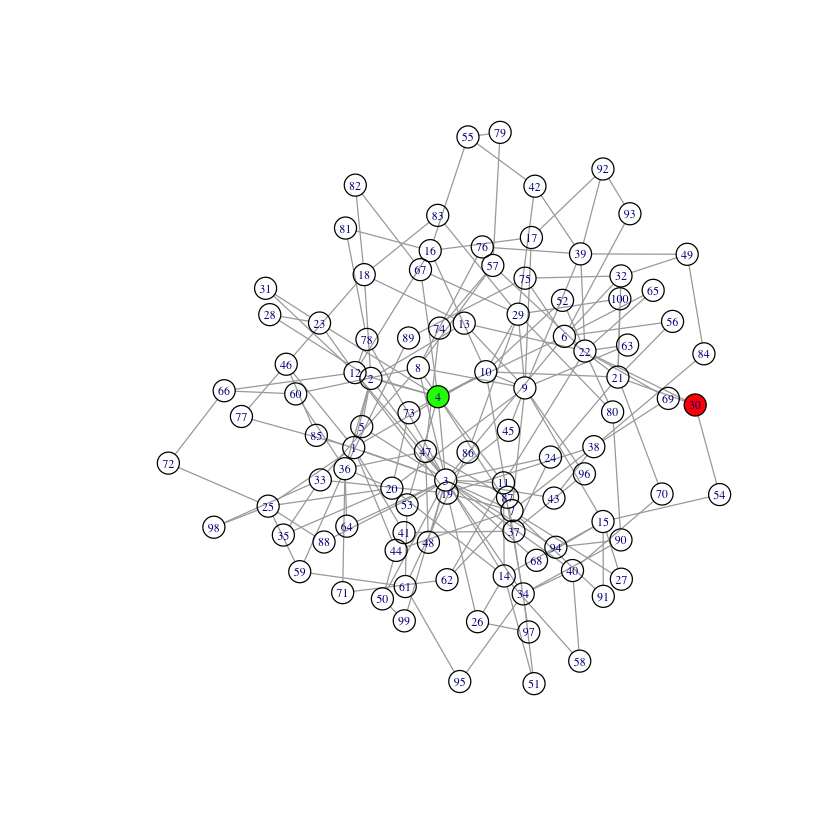

In [18]:
V(g)[30]$color <- 'red'
V(g)[4]$color <- 'green'
plot(g, layout=lay, vertex.size=8, 
vertex.label.cex=0.6)

[[1]]
 [1] 1 2 2 1 1 1 2 2 2 2 1 2 3 3 1 3 1 1 2 3 1 2 2 2 2 2 1 3 1 2


[1] "merges"     "modularity" "membership" "vcount"     "algorithm"

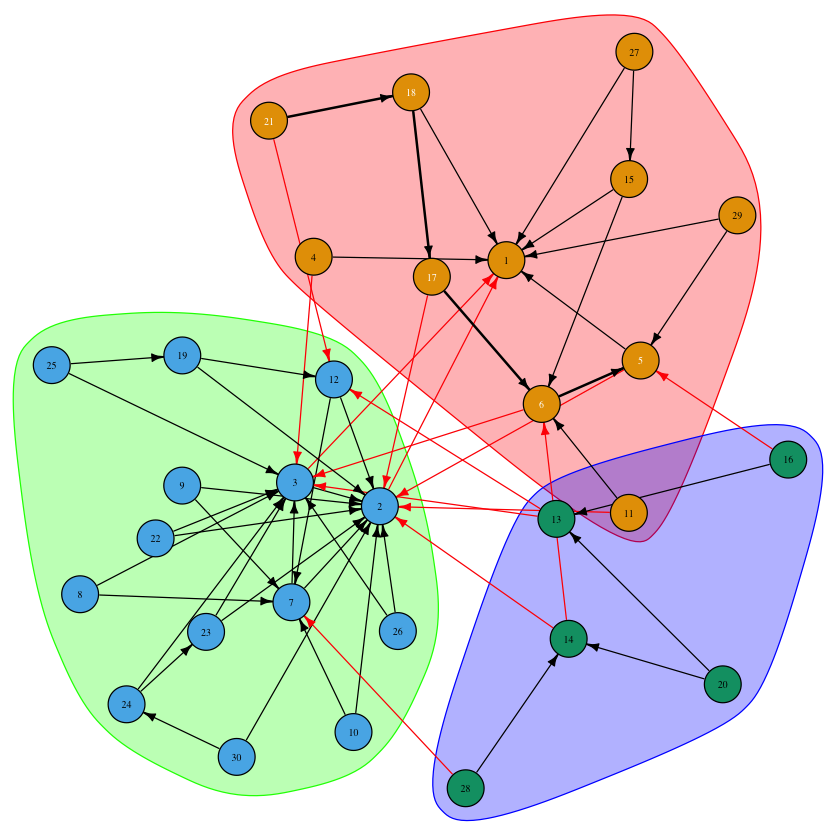

In [19]:
# Modularity

# Use a community detection algorithm to determine the most densely 
# connected nodes in a graph.
 
g.community<-cluster_walktrap(test.graph)
 
# This algorithm uses random walks to find the most densely connected subgraphs.
 
members<-membership(g.community)
# The members() function picks out the membership vector 
# (list of nodes in the most densely connected subgraph) from 
# the communtiy object (e.g., walktrap community).
list(members)

par(mar=c(.1,.1,.1,.1))    # sets the edges of the plotting area
names(g.community)
plot(g.community, test.graph, layout=layout.fruchterman.reingold,
vertex.size=10,
vertex.label.cex=.5,
edge.arrow.size=.5)

[1] "merges"     "modularity" "membership" "vcount"     "algorithm"

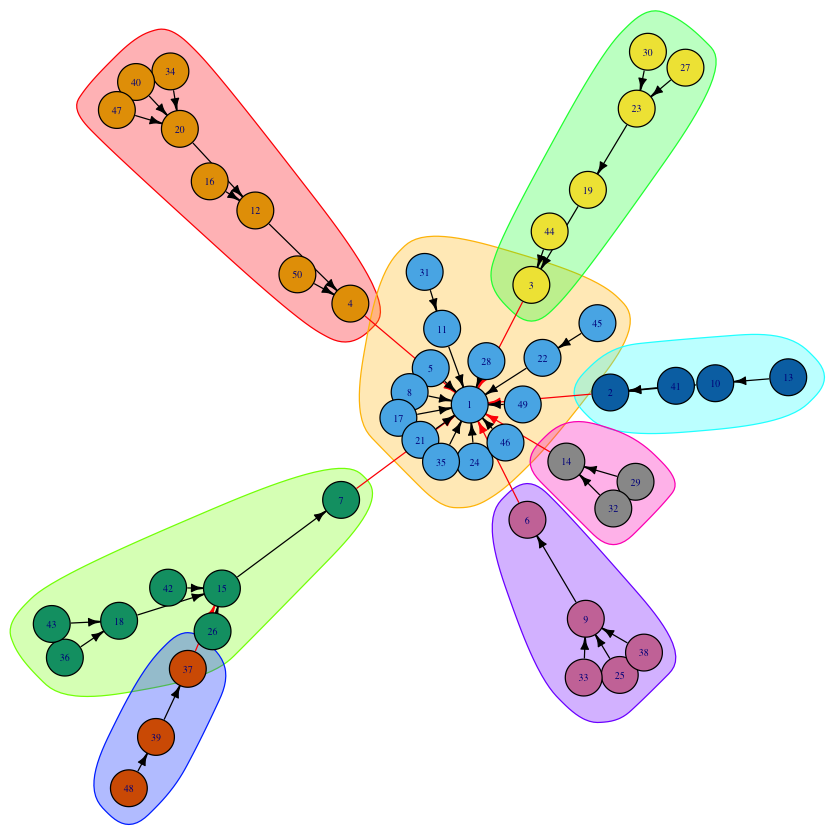

In [24]:
# Repeat with a simpler graph
test.graph.1 <- sample_pa(n=50,power=1)
g.community<-cluster_walktrap(test.graph.1) 
members<-membership(g.community)

par(mar=c(.1,.1,.1,.1))    # sets the edges of the plotting area
names(g.community)
plot(g.community, test.graph.1, layout=layout.fruchterman.reingold,
vertex.size=10,
vertex.label.cex=.5,
edge.arrow.size=.5)